# Market Regime Analysis

How does the predictive power of simple stock-level signals change with observable market conditions?

Companion to the cross-sectional signal project, which measured unconditional rank IC for a set of price and volume signals on the same data. This notebook takes four of those signals (12-1 momentum, short-term reversal, realised volatility, volume surprise) and asks whether their relationship with next-month returns depends on the market state at the time of the forecast. Market state is summarised by realised index volatility (primary) and index trend (secondary), regimes are defined with expanding-window quantiles so that no future information enters, and the main outputs are regime-conditional rank IC with HAC inference, a rolling view through time, and a transfer experiment in which signal weights calibrated in one regime are evaluated in another out of sample.

Data: Yahoo Finance daily prices for the current S&P 1500 constituents, 2004 to 2026, cached from the first project and rebuilt here if missing. The numbers quoted in the text correspond to data downloaded on 2026-09-18.

## 1. Setup

In [1]:
import io, logging, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm

try:
    import yfinance as yf
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'yfinance'], check=True)
    import yfinance as yf

warnings.filterwarnings('ignore')
logging.getLogger('yfinance').setLevel(logging.CRITICAL)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.figsize': (8, 4), 'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9})

IN_COLAB = 'google.colab' in sys.modules
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

START = '2004-01-01'
TRAIN_END = pd.Timestamp('2015-12-31')      # calibration period for the transfer experiment
MIN_PRICE, MIN_DOLLAR_VOL, MIN_OBS = 5.0, 1e6, 200
FEATS = ['mom_12m', 'rev_1m', 'rvol_3m', 'vol_surp']
REGIME_NAMES = {0: 'low vol', 1: 'mid vol', 2: 'high vol'}
t_start = time.time()
print('python', sys.version.split()[0], '| pandas', pd.__version__, '| colab:', IN_COLAB)

python 3.14.2 | pandas 3.0.6 | colab: False


## 2. Data

Same source and universe as the first project: daily `Adj Close`, `Close` and `Volume` from Yahoo Finance for the current S&P 500, 400 and 600 members, plus SPY as the market. The stock panel is cached under `data/`; if the cache is missing (for example on Colab) it is downloaded again, which takes a few minutes. A separate, longer SPY history from 1993 is used for the market-state variables so that the expanding regime thresholds have a burn-in period before the stock panel starts in 2005.

Cleaning follows the first project: days where the implied dividend adjustment exceeds 50% or the unadjusted price moves by more than +150% or less than -80% are treated as vendor errors and given a zero return, and a clean total-return index is rebuilt from daily returns.

Survivorship: the ticker list is today's constituent list, so firms that were delisted before September 2026 are absent. Using the 1500 rather than the 500 keeps names that were demoted after large drawdowns, but not those that disappeared. The regime results inherit this bias, and it is not neutral across regimes: surviving stocks that fell sharply during high-volatility episodes later recovered by construction, which should flatter contrarian behaviour (reversal, high volatility) in and after such episodes.

In [2]:
def wiki_constituents():
    pages = {'sp500': 'List_of_S%26P_500_companies', 'sp400': 'List_of_S%26P_400_companies',
             'sp600': 'List_of_S%26P_600_companies'}
    frames = []
    for name, page in pages.items():
        html = requests.get(f'https://en.wikipedia.org/wiki/{page}', headers={'User-Agent': 'Mozilla/5.0'}, timeout=30).text
        t = pd.read_html(io.StringIO(html))[0][['Symbol', 'Security', 'GICS Sector']]
        t['index'] = name
        frames.append(t)
    cons = pd.concat(frames, ignore_index=True)
    cons['ticker'] = cons['Symbol'].str.replace('.', '-', regex=False)
    return cons.drop_duplicates('ticker').reset_index(drop=True)

cons_file, price_file, spy_file = DATA_DIR / 'constituents.csv', DATA_DIR / 'prices.parquet', DATA_DIR / 'spy_long.parquet'
cons = pd.read_csv(cons_file) if cons_file.exists() else wiki_constituents()
cons.to_csv(cons_file, index=False)
tickers = sorted(cons['ticker'])
if price_file.exists():
    raw = pd.read_parquet(price_file)
else:
    raw = yf.download(tickers + ['SPY'], start=START, auto_adjust=False, progress=False,
                      threads=True, group_by='column')[['Adj Close', 'Close', 'Volume']]
    raw.to_parquet(price_file)
raw.index = pd.to_datetime(raw.index)
if spy_file.exists():
    spy = pd.read_parquet(spy_file)
else:
    spy = yf.download('SPY', start='1993-01-01', auto_adjust=False, progress=False)[['Adj Close']]
    spy.columns = spy.columns.get_level_values(0)
    spy.to_parquet(spy_file)
spy.index = pd.to_datetime(spy.index)
print('stock panel:', raw.shape, raw.index[0].date(), 'to', raw.index[-1].date(), '| SPY history from', spy.index[0].date())

adj, close, vol = raw['Adj Close'], raw['Close'], raw['Volume']
have = adj.notna().sum() > 0
adj, close, vol = adj.loc[:, have], close.loc[:, have], vol.loc[:, have]
mkt = adj.pop('SPY')
close, vol = close.drop(columns='SPY'), vol.drop(columns='SPY')
adj, close, vol = adj.where(adj > 0), close.where(close > 0), vol.where(vol > 0)

la = np.log(adj.ffill()).diff().where(adj.notna())
lc = np.log(close.ffill()).diff().where(close.notna())
bad = ((la - lc).abs() > np.log(1.5)) | (lc > np.log(2.5)) | (lc < np.log(0.2))
la = la.mask(bad, 0.0)
tr = np.exp(la.fillna(0).cumsum()).where(adj.notna())
dret = np.expm1(la)
mret = np.expm1(np.log(mkt).diff())

dates = adj.index
month_end = pd.Series(dates, index=dates).groupby(dates.to_period('M')).last()
month_end = month_end[month_end.index < dates[-1].to_period('M')]
me = pd.DatetimeIndex(month_end.values)
print(f'flagged vendor-error days: {int(bad.sum().sum())} | tickers: {adj.shape[1]} | month ends: {len(me)} ({me[0].date()} to {me[-1].date()})')

stock panel: (5714, 4521) 2004-01-02 to 2026-09-18 | SPY history from 1993-01-29
flagged vendor-error days: 54 | tickers: 1503 | month ends: 272 (2004-01-30 to 2026-08-31)


## 3. Market-state construction

Candidate state variables, all computed from SPY at each month-end t using data up to t only:

- `mvol_63`: annualised standard deviation of daily SPY log returns over the last 63 trading days
- `mvol_21`: same over 21 days (used as a robustness check)
- `trend`: SPY relative to its 200-day moving average, minus 1
- `drawdown`: SPY relative to its trailing 252-day high, minus 1

Cross-sectional return dispersion is computed later from the stock panel for comparison but is not used as a regime variable: it only exists from 2005, so it would have no burn-in for the expanding thresholds, and it is fairly correlated with realised volatility anyway. Realised volatility is the primary state variable because it is the most standard, it is persistent enough that a regime defined at t still describes the following month, and there is a clear prior that momentum and low-volatility strategies behave differently in turbulent markets. Trend is kept as a secondary binary cut (above or below the 200-day average).

In [3]:
sret = np.log(spy['Adj Close']).diff()
spy_me = pd.DatetimeIndex(pd.Series(spy.index, index=spy.index).groupby(spy.index.to_period('M')).last().values)
state = pd.DataFrame({
    'mvol_63': (sret.rolling(63).std() * np.sqrt(252)).reindex(spy_me),
    'mvol_21': (sret.rolling(21).std() * np.sqrt(252)).reindex(spy_me),
    'trend': (spy['Adj Close'] / spy['Adj Close'].rolling(200).mean() - 1).reindex(spy_me),
    'drawdown': (spy['Adj Close'] / spy['Adj Close'].rolling(252).max() - 1).reindex(spy_me),
})
print('month-end observations:', len(state), '| first full 63-day vol:', state['mvol_63'].first_valid_index().date())
state.describe().T[['mean', 'std', 'min', '50%', 'max']].round(3)

month-end observations: 405 | first full 63-day vol: 1993-04-30
Out[3]: 
           mean    std    min    50%    max
mvol_63   0.163  0.090  0.056  0.138  0.707
mvol_21   0.158  0.099  0.050  0.134  0.916
trend     0.041  0.076 -0.309  0.054  0.199
drawdown -0.057  0.080 -0.473 -0.024  0.000


## 4. Signal construction

Four signals from the first project, chosen because they have low mutual correlation and each has a clear prior about regime dependence:

| signal | definition |
|---|---|
| `mom_12m` | total return from month t-12 to t-1 |
| `rev_1m` | minus the return over month t-1 to t |
| `rvol_3m` | annualised standard deviation of daily returns over the last 63 days |
| `vol_surp` | log of mean volume over the last 21 days minus log of mean volume over the prior 126 days |

Universe at each month-end: price above 5 dollars, 63-day median dollar volume of at least 1 million, at least 200 valid daily returns in the past year, 12 months of history. The forward return is the 1-month return from t to t+1 minus the ex-ante beta (252 daily returns against SPY) times the SPY return, as in the first project. Signals are compared with forward returns by rank, so no winsorisation is needed for the IC tests; winsorised z-scores are used only for the combined scores in section 7.

In [4]:
nobs = dret.notna().rolling(252).sum()
dvol = (close * vol).rolling(63, min_periods=40).median()
P = tr.reindex(me)
elig = ((close.reindex(me) > MIN_PRICE) & (dvol.reindex(me) >= MIN_DOLLAR_VOL)
        & (nobs.reindex(me) >= MIN_OBS) & P.notna() & P.shift(12).notna())

rv = dret.rolling(63, min_periods=50).std() * np.sqrt(252)
vsurp = np.log(vol.rolling(21, min_periods=15).mean()) - np.log(vol.shift(21).rolling(126, min_periods=90).mean())
beta = dret.rolling(252, min_periods=200).cov(mret).div(mret.rolling(252, min_periods=200).var(), axis=0)
beta_m = beta.reindex(me).clip(0.0, 3.0)
Pm = mkt.reindex(me)

cols = {
    'mom_12m': P.shift(1) / P.shift(12) - 1,
    'rev_1m': -(P / P.shift(1) - 1),
    'rvol_3m': rv.reindex(me),
    'vol_surp': vsurp.reindex(me),
    'beta': beta_m,
}
for h in (1, 3):
    fwd = P.shift(-h) / P - 1
    cols[f'fwd_{h}'] = fwd
    cols[f'fwdadj_{h}'] = fwd - beta_m.mul(Pm.shift(-h) / Pm - 1, axis=0)

panel = pd.concat({k: v.where(elig).stack() for k, v in cols.items()}, axis=1)
panel.index.names = ['date', 'ticker']
panel = panel.dropna(subset=FEATS + ['beta'])
pdates = panel.index.get_level_values('date')
print('stock-months:', len(panel), '| months:', pdates.nunique(), '| first:', pdates.min().date(), '| last:', pdates.max().date())
print('average universe size by year:')
print(panel.groupby(level='date').size().groupby(pdates.unique().year).mean().round(0).astype(int).to_frame('n').T.to_string())

stock-months: 297907 | months: 260 | first: 2005-01-31 | last: 2026-08-31
average universe size by year:
date  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
n      772   836   892   890   859   917   957   973  1030  1092  1141  1183  1228  1270  1300  1325  1375  1416  1439  1462  1478  1486


## 5. Regime definition

Volatility regime at month-end t: `mvol_63` at t is compared with the terciles of its own history up to t-1 (expanding window starting in 1993, at least 60 months of history before the first assignment). Below the lower tercile is `low vol`, above the upper tercile is `high vol`, in between is `mid vol`. Only past values enter the thresholds, so the label at t is known at t and would have been the same label in real time. Because the thresholds keep updating, the three regimes are not equally frequent within 2005-2026: the high-vol threshold drifts up during 2008-2009 and the calm 2010s then fall mostly into the low and mid groups.

Trend regime: `up` if SPY is above its 200-day moving average at t, `down` otherwise. No threshold needs estimating.

The regime label used for a forecast made at t is the label at t, not the label during the forward month. Conditioning on the state during the forward month would use information that is not available when the forecast is made.

months by volatility regime (2005-2026): {'low vol': 104, 'mid vol': 100, 'high vol': 68}
months by trend regime: {'up': 222, 'down': 50}
cross-tabulation:
trend_regime  down   up
vol_regime             
high vol        42   26
low vol          0  104
mid vol          8   92


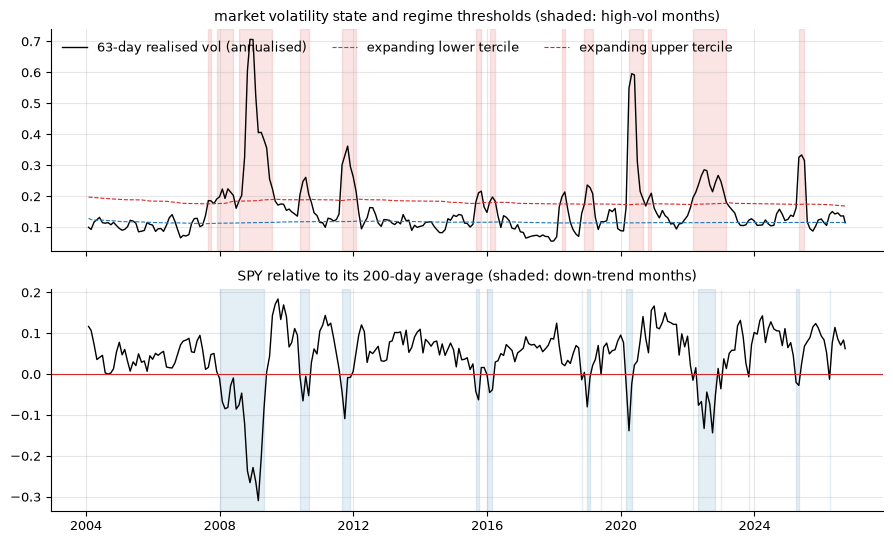

In [5]:
def expanding_tercile(x, min_obs=60):
    lo = x.expanding(min_obs).quantile(1 / 3).shift(1)   # thresholds from history up to t-1
    hi = x.expanding(min_obs).quantile(2 / 3).shift(1)
    r = pd.Series(np.where(x > hi, 2, np.where(x > lo, 1, 0)), index=x.index, dtype=float).where(hi.notna())
    return r, lo, hi

state['vol_regime'], state['thr_lo'], state['thr_hi'] = expanding_tercile(state['mvol_63'])
state['trend_regime'] = (state['trend'] > 0).astype(int)
st = state.reindex(me).dropna(subset=['vol_regime'])
print('months by volatility regime (2005-2026):', st['vol_regime'].map(REGIME_NAMES).value_counts().to_dict())
print('months by trend regime:', st['trend_regime'].map({1: 'up', 0: 'down'}).value_counts().to_dict())
print('cross-tabulation:')
print(pd.crosstab(st['vol_regime'].map(REGIME_NAMES), st['trend_regime'].map({1: 'up', 0: 'down'})).to_string())

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
s = state.loc['2004':]
axes[0].plot(s.index, s['mvol_63'], color='k', lw=1, label='63-day realised vol (annualised)')
axes[0].plot(s.index, s['thr_lo'], color='C0', lw=0.8, ls='--', label='expanding lower tercile')
axes[0].plot(s.index, s['thr_hi'], color='C3', lw=0.8, ls='--', label='expanding upper tercile')
axes[0].fill_between(s.index, 0, 1, where=s['vol_regime'] == 2, transform=axes[0].get_xaxis_transform(), color='C3', alpha=0.12)
axes[0].legend(frameon=False, ncol=3); axes[0].set_title('market volatility state and regime thresholds (shaded: high-vol months)', fontsize=10)
axes[1].plot(s.index, s['trend'], color='k', lw=1)
axes[1].axhline(0, color='C3', lw=0.8)
axes[1].fill_between(s.index, 0, 1, where=s['trend_regime'] == 0, transform=axes[1].get_xaxis_transform(), color='C0', alpha=0.12)
axes[1].set_title('SPY relative to its 200-day average (shaded: down-trend months)', fontsize=10)
fig.tight_layout()

## 6. Signal behaviour across regimes

Rank IC is the Spearman correlation between a signal and the beta-adjusted 1-month forward return within a month. For each signal: full-sample mean IC, IC standard deviation, information ratio (mean over standard deviation, monthly), a Newey-West t-statistic with one lag, and the share of months with positive IC. Signals are tested with their natural sign, so a negative IC for `rvol_3m` means low-volatility stocks did better.

The regime comparison then groups the monthly IC series by the regime label at t. Differences between regimes are tested by regressing the IC series on regime dummies with HAC standard errors (one lag), which handles the fact that regimes come in runs of consecutive months. With four signals and two regime variables there are eight difference tests in this section, so a single |t| near 2 should not be read as strong evidence; the two prior hypotheses (momentum and low volatility weaken in turbulent markets) are the ones worth taking seriously if they show up.

In [6]:
def rank_ic(df, cols, target):
    d = df[[target] + cols].dropna(subset=[target])
    rk = d.groupby(level='date').rank()
    rk = rk - rk.groupby(level='date').transform('mean')
    num = rk[cols].mul(rk[target], axis=0).groupby(level='date').sum()
    den = np.sqrt((rk[cols] ** 2).groupby(level='date').sum().mul((rk[target] ** 2).groupby(level='date').sum(), axis=0))
    return num / den

def ic_summary(ic, lags=1):
    ic = ic.dropna()
    ols = sm.OLS(ic.values, np.ones(len(ic))).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return pd.Series({'mean_ic': ic.mean(), 'ic_std': ic.std(), 'icir': ic.mean() / ic.std(),
                      't_nw': ols.tvalues[0], 'hit_rate': (ic > 0).mean(), 'n_months': len(ic)})

def regime_diff(ic, regime, lags=1):
    # regress the monthly IC on regime dummies (base = regime 0); returns coefficient and NW t per dummy
    d = pd.get_dummies(regime.dropna().astype(int), prefix='r', drop_first=True).astype(float)
    m = sm.OLS(ic.reindex(d.index).values, sm.add_constant(d).values).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return pd.Series(m.params[1:], index=d.columns), pd.Series(m.tvalues[1:], index=d.columns)

IC = rank_ic(panel, FEATS, 'fwdadj_1')
vol_reg = st['vol_regime'].reindex(IC.index)
trend_reg = st['trend_regime'].reindex(IC.index)
print('full sample, 1-month horizon, beta-adjusted returns')
pd.DataFrame({f: ic_summary(IC[f]) for f in FEATS}).T.round(3)

full sample, 1-month horizon, beta-adjusted returns
Out[6]: 
          mean_ic  ic_std   icir   t_nw  hit_rate  n_months
mom_12m    -0.003   0.151 -0.019 -0.304     0.517     259.0
rev_1m      0.009   0.113  0.084  1.397     0.494     259.0
rvol_3m    -0.028   0.164 -0.170 -2.775     0.425     259.0
vol_surp   -0.005   0.060 -0.092 -1.573     0.467     259.0


In [7]:
def by_regime(regime, names, lags=1):
    rows = {}
    for f in FEATS:
        for k in sorted(regime.dropna().unique()):
            rows[(f, names[int(k)])] = ic_summary(IC[f][regime == k], lags)
    return pd.DataFrame(rows).T

vol_tab = by_regime(vol_reg, REGIME_NAMES)
diffs = pd.DataFrame({f: pd.concat(regime_diff(IC[f], vol_reg)) for f in FEATS}).T
diffs.columns = ['mid - low', 'high - low', 't (mid - low)', 't (high - low)']
print('by volatility regime at t')
display(vol_tab.round(3))
print('difference in mean IC relative to the low-vol regime, with Newey-West t')
diffs.round(3)

by volatility regime at t
difference in mean IC relative to the low-vol regime, with Newey-West t
Out[7]: 
          mid - low  high - low  t (mid - low)  t (high - low)
mom_12m      -0.050      -0.045         -2.556          -1.800
rev_1m        0.015       0.010          1.000           0.510
rvol_3m       0.017       0.059          0.726           2.501
vol_surp     -0.010       0.004         -1.253           0.394


mean_ic  ic_std   icir   t_nw  hit_rate  n_months
mom_12m  low vol     0.028   0.129  0.215  2.178     0.553      94.0
         mid vol    -0.022   0.147 -0.150 -1.589     0.515      97.0
         high vol   -0.017   0.177 -0.099 -0.839     0.471      68.0
rev_1m   low vol     0.001   0.106  0.012  0.119     0.532      94.0
         mid vol     0.016   0.109  0.149  1.615     0.495      97.0
         high vol    0.011   0.129  0.086  0.710     0.441      68.0
rvol_3m  low vol    -0.050   0.152 -0.327 -3.839     0.330      94.0
         mid vol    -0.033   0.174 -0.190 -1.784     0.454      97.0
         high vol    0.009   0.163  0.058  0.507     0.515      68.0
vol_surp low vol    -0.003   0.057 -0.048 -0.456     0.489      94.0
         mid vol    -0.013   0.057 -0.224 -2.489     0.412      97.0
         high vol    0.001   0.067  0.015  0.133     0.515      68.0

In [8]:
trend_tab = by_regime(trend_reg, {1: 'up', 0: 'down'})
tdiff = pd.DataFrame({f: pd.concat(regime_diff(IC[f], trend_reg)) for f in FEATS}).T
tdiff.columns = ['up - down', 't (up - down)']
print('by trend regime at t')
display(trend_tab.round(3))
tdiff.round(3)

by trend regime at t
Out[8]: 
          up - down  t (up - down)
mom_12m       0.031          1.174
rev_1m       -0.005         -0.259
rvol_3m      -0.015         -0.606
vol_surp     -0.006         -0.662


mean_ic  ic_std   icir   t_nw  hit_rate  n_months
mom_12m  down   -0.028   0.172 -0.164 -1.110     0.460      50.0
         up      0.003   0.145  0.023  0.329     0.531     209.0
rev_1m   down    0.014   0.144  0.096  0.729     0.460      50.0
         up      0.008   0.105  0.080  1.201     0.502     209.0
rvol_3m  down   -0.016   0.153 -0.107 -0.758     0.440      50.0
         up     -0.031   0.167 -0.184 -2.725     0.421     209.0
vol_surp down   -0.001   0.059 -0.013 -0.093     0.520      50.0
         up     -0.007   0.060 -0.110 -1.654     0.455     209.0

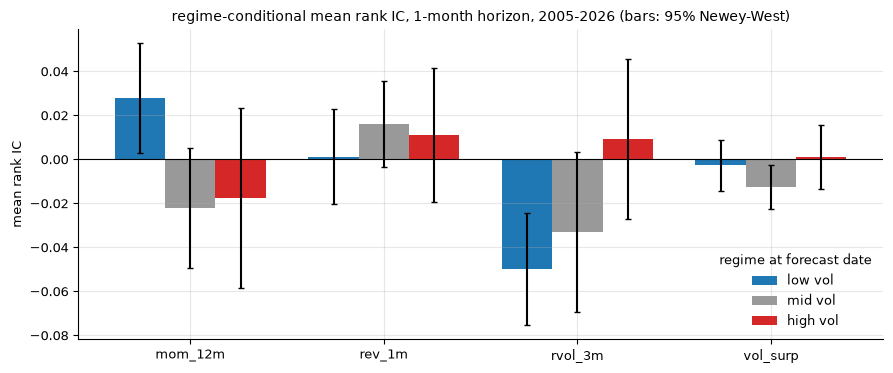

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(FEATS)); w = 0.26
for i, k in enumerate((0, 1, 2)):
    m = vol_tab.xs(REGIME_NAMES[k], level=1)['mean_ic']
    se = (m / vol_tab.xs(REGIME_NAMES[k], level=1)['t_nw']).abs()
    ax.bar(x + (i - 1) * w, m, w, yerr=1.96 * se, capsize=2, label=REGIME_NAMES[k], color=['C0', '0.6', 'C3'][i])
ax.axhline(0, color='k', lw=0.8); ax.set_xticks(x); ax.set_xticklabels(FEATS)
ax.set_ylabel('mean rank IC'); ax.legend(frameon=False, title='regime at forecast date')
ax.set_title('regime-conditional mean rank IC, 1-month horizon, 2005-2026 (bars: 95% Newey-West)', fontsize=10)
fig.tight_layout()

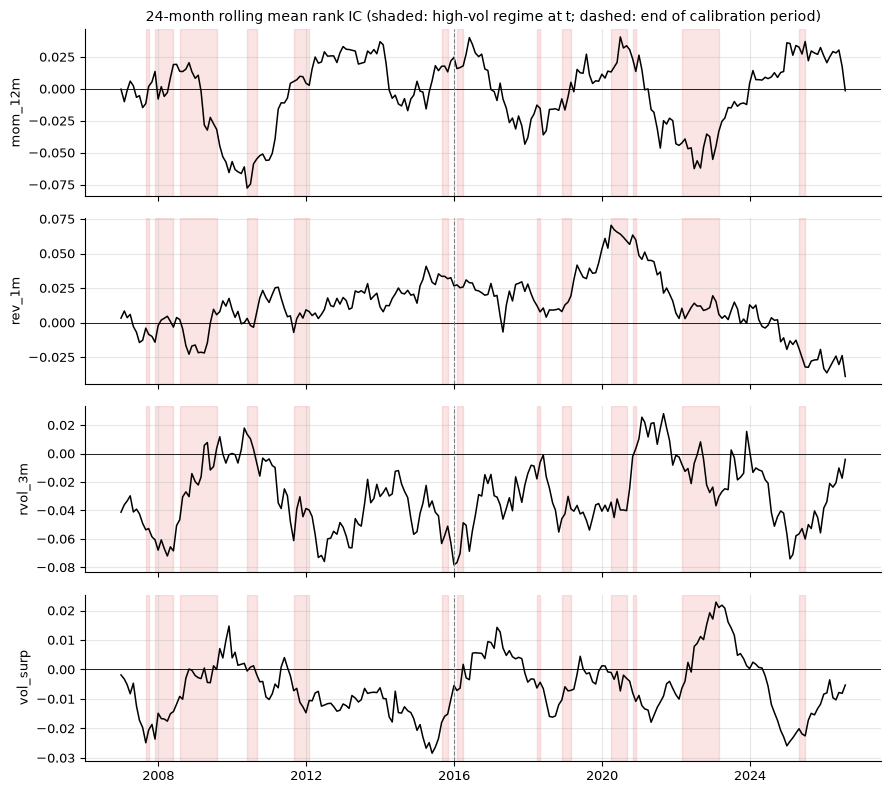

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
roll = IC.rolling(24).mean()
for ax, f in zip(axes, FEATS):
    ax.plot(roll.index, roll[f], color='k', lw=1.1)
    ax.axhline(0, color='k', lw=0.6)
    ax.fill_between(vol_reg.index, 0, 1, where=vol_reg == 2, transform=ax.get_xaxis_transform(), color='C3', alpha=0.12)
    ax.axvline(TRAIN_END, color='0.5', ls='--', lw=0.8)
    ax.set_ylabel(f)
axes[0].set_title('24-month rolling mean rank IC (shaded: high-vol regime at t; dashed: end of calibration period)', fontsize=10)
fig.tight_layout()

## 7. Regime transfer

Question: does knowing the market state at the forecast date help out of sample? The design keeps the model as simple as possible so that the answer is about the conditioning, not the model.

- Calibration period 2005-01 to 2015-12, evaluation period 2016-01 to 2026-07. Nothing from the evaluation period enters any weight.
- A signal weight vector is the mean 1-month IC of each signal over a set of calibration months. Four such vectors are estimated: one per volatility regime (using only calibration months with that label) and one from all calibration months. This is the heavy-shrinkage limit of the Ridge combination in the first project and is transparent.
- A combined score is the weighted sum of the winsorised, z-scored signals. The `unconditional` score uses the all-months weights everywhere. The `conditional` score uses, at each evaluation month t, the weights of the regime observed at t.
- The transfer matrix reports the evaluation-period mean IC of each fixed weight vector within each evaluation-period regime, i.e. how a model calibrated in one environment performs in each environment later.

For a single signal the only thing that can be calibrated is its sign, so the single-signal version of the experiment is simply whether the calibration-period sign within a regime carries over to that regime in the evaluation period.

In [11]:
def winsorize_cs(df, cols, lo=0.01, hi=0.99):
    g = df.groupby(level='date')[cols]
    return df[cols].clip(g.transform('quantile', lo), g.transform('quantile', hi))

def standardize_cs(df):
    g = df.groupby(level='date')
    return (df - g.transform('mean')) / g.transform('std')

Z = standardize_cs(winsorize_cs(panel, FEATS))
calib = IC.index <= TRAIN_END
evalm = IC.index > TRAIN_END
print('calibration months by regime:', vol_reg[calib].map(REGIME_NAMES).value_counts().to_dict())
print('evaluation months by regime: ', vol_reg[evalm].map(REGIME_NAMES).value_counts().to_dict())

W = {REGIME_NAMES[k]: IC.loc[calib & (vol_reg == k).values, FEATS].mean() for k in (0, 1, 2)}
W['all months'] = IC.loc[calib, FEATS].mean()
W = pd.DataFrame(W).T
print('calibration-period mean IC used as weights:')
display(W.round(4))

reg_rows = vol_reg.reindex(pdates).map(REGIME_NAMES).values
scores = {name: (Z[FEATS] * W.loc[name]).sum(axis=1) for name in W.index}
scores['conditional'] = pd.Series(np.select([reg_rows == n for n in REGIME_NAMES.values()],
                                            [scores[n] for n in REGIME_NAMES.values()], np.nan), index=panel.index)
S = pd.DataFrame(scores)
S_IC = rank_ic(pd.concat([S, panel['fwdadj_1']], axis=1), list(S.columns), 'fwdadj_1')
ev_ic = S_IC[evalm]
ev_reg = vol_reg[evalm].map(REGIME_NAMES)
transfer = pd.DataFrame({n: ev_ic[ev_reg == n].mean() for n in REGIME_NAMES.values()})
transfer['all evaluation months'] = ev_ic.mean()
transfer.index.name = 'weights calibrated on'
transfer.columns.name = 'evaluation regime'
print('transfer matrix: evaluation-period (2016-2026) mean rank IC')
transfer.round(4)

calibration months by regime: {'low vol': 50, 'mid vol': 47, 'high vol': 35}
evaluation months by regime:  {'mid vol': 50, 'low vol': 44, 'high vol': 33}
calibration-period mean IC used as weights:
transfer matrix: evaluation-period (2016-2026) mean rank IC
Out[11]: 
evaluation regime      low vol  mid vol  high vol  all evaluation months
weights calibrated on                                                   
low vol                 0.0743  -0.0112   -0.0329                 0.0128
mid vol                 0.0629   0.0155   -0.0328                 0.0194
high vol                0.0074   0.0462   -0.0084                 0.0186
all months              0.0653   0.0141   -0.0346                 0.0192
conditional             0.0743   0.0155   -0.0084                 0.0297


,mom_12m,rev_1m,rvol_3m,vol_surp
low vol,0.0220,0.0005,-0.0337,-0.0038
mid vol,0.0056,0.0163,-0.0558,-0.0127
high vol,-0.0248,0.0081,-0.0179,-0.0032
all months,0.0037,0.0081,-0.0374,-0.0068


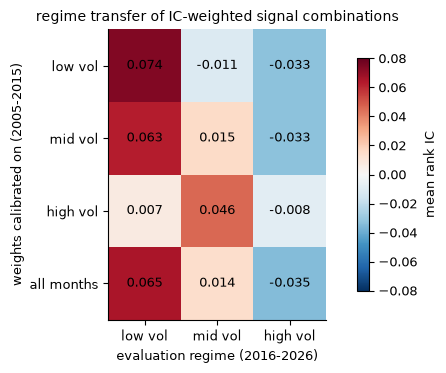

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
tm = transfer.iloc[:4, :3]
im = ax.imshow(tm.values, cmap='RdBu_r', vmin=-0.08, vmax=0.08)
ax.set_xticks(range(3)); ax.set_xticklabels(tm.columns); ax.set_yticks(range(4)); ax.set_yticklabels(tm.index); ax.grid(False)
for i in range(tm.shape[0]):
    for j in range(tm.shape[1]):
        ax.text(j, i, f'{tm.values[i, j]:.3f}', ha='center', va='center', fontsize=9)
ax.set_xlabel('evaluation regime (2016-2026)'); ax.set_ylabel('weights calibrated on (2005-2015)')
fig.colorbar(im, ax=ax, shrink=0.8, label='mean rank IC'); ax.set_title('regime transfer of IC-weighted signal combinations', fontsize=10)
fig.tight_layout()

In [13]:
comp = pd.DataFrame({'unconditional': ic_summary(ev_ic['all months']), 'conditional': ic_summary(ev_ic['conditional']),
                     'conditional - unconditional': ic_summary(ev_ic['conditional'] - ev_ic['all months'])}).T
print('evaluation period 2016-2026, combined scores')
display(comp.round(3))
print('same scores over the calibration period (in-sample, for reference):',
      S_IC.loc[calib, ['all months', 'conditional']].mean().round(4).to_dict())

sign_rows = {}
for f in FEATS:
    for k in (0, 1, 2):
        sign_rows[(f, REGIME_NAMES[k])] = {'calibration sign': int(np.sign(W.loc[REGIME_NAMES[k], f])),
                                          'calibration IC': W.loc[REGIME_NAMES[k], f],
                                          'evaluation IC': IC[f][evalm & (vol_reg == k).values].mean(),
                                          'evaluation months': int((evalm & (vol_reg == k).values).sum())}
sign_tab = pd.DataFrame(sign_rows).T
sign_tab['sign carried over'] = np.sign(sign_tab['calibration IC']) == np.sign(sign_tab['evaluation IC'])
print('single-signal sign transfer by regime')
sign_tab.round(4)

evaluation period 2016-2026, combined scores
same scores over the calibration period (in-sample, for reference): {'all months': 0.0389, 'conditional': 0.046}
single-signal sign transfer by regime
Out[13]: 
                   calibration sign  calibration IC  evaluation IC  evaluation months  sign carried over
mom_12m  low vol                1.0          0.0220         0.0342               44.0               True
         mid vol                1.0          0.0056        -0.0481               50.0              False
         high vol              -1.0         -0.0248        -0.0097               33.0               True
rev_1m   low vol                1.0          0.0005         0.0023               44.0               True
         mid vol                1.0          0.0163         0.0161               50.0               True
         high vol               1.0          0.0081         0.0142               33.0               True
rvol_3m  low vol               -1.0         -0.0337        

,mean_ic,ic_std,icir,t_nw,hit_rate,n_months
unconditional,0.019,0.166,0.115,1.328,0.535,127.0
conditional,0.030,0.158,0.188,2.204,0.559,127.0
conditional - unconditional,0.010,0.111,0.094,1.066,0.591,127.0


Economic link. A small check that the IC differences correspond to portfolio behaviour: beta-neutral decile long-short portfolios built as in the first project (long top decile, short bottom decile, equal weight within legs, short leg scaled to zero ex-ante beta, gross notional 2, monthly rebalance), for the two signals with the clearest regime pattern, with monthly returns grouped by the regime at the rebalance date. Then the same construction for the unconditional and conditional combined scores over the evaluation period, with turnover and a flat cost per unit of turnover. This is deliberately brief; the full backtest treatment is in the first project.

In [14]:
def decile_ls(score, ret, beta, q=10):
    d = pd.concat([score.rename('s'), ret.rename('r'), beta.rename('b')], axis=1).dropna()
    rk = d.groupby(level='date')['s'].rank(pct=True)
    w = pd.Series(0.0, index=d.index)
    w[rk > 1 - 1 / q] = 1.0
    w[rk <= 1 / q] = -1.0
    dts = w.index.get_level_values('date')
    n_long = w[w > 0].groupby(level='date').count().reindex(dts).values
    n_short = w[w < 0].groupby(level='date').count().reindex(dts).values
    w = w.where(w <= 0, w / n_long).where(w >= 0, w / n_short)
    b_long = (w.clip(lower=0) * d['b']).groupby(level='date').sum()
    b_short = (-w.clip(upper=0) * d['b']).groupby(level='date').sum()
    w = w.where(w >= 0, w * (b_long / b_short).reindex(dts).values)
    w = 2 * w / w.abs().groupby(level='date').sum().reindex(dts).values
    pret = (w * d['r']).groupby(level='date').sum()
    Wm = w.unstack().fillna(0.0)
    turnover = Wm.diff().abs().sum(axis=1)
    turnover.iloc[0] = Wm.iloc[0].abs().sum()
    return pret, turnover

def perf(pret, turnover, cost_bps=0):
    rr = pret - turnover * cost_bps / 1e4
    cum = (1 + rr).cumprod()
    return pd.Series({'ann_ret': rr.mean() * 12, 'ann_vol': rr.std() * np.sqrt(12), 'sharpe': rr.mean() / rr.std() * np.sqrt(12),
                      'max_dd': (cum / cum.cummax() - 1).min(), 'turnover': turnover.mean()})

rows = {}
ls_ret = {}
for name, sc in [('momentum (long high)', Z['mom_12m']), ('low volatility (long low vol)', -Z['rvol_3m'])]:
    pret, to = decile_ls(sc, panel['fwd_1'], panel['beta'])
    ls_ret[name] = pret
    r = vol_reg.reindex(pret.index)
    for k in (0, 1, 2):
        x = pret[r == k]
        rows[(name, REGIME_NAMES[k])] = {'mean monthly ret %': x.mean() * 100, 'sharpe': x.mean() / x.std() * np.sqrt(12), 'months': len(x)}
print('decile long-short monthly returns grouped by volatility regime at the rebalance date, 2005-2026, gross of costs')
display(pd.DataFrame(rows).T.round(2))

ev_rows = pdates > TRAIN_END
port = {n: decile_ls(S[n][ev_rows], panel['fwd_1'][ev_rows], panel['beta'][ev_rows]) for n in ['all months', 'conditional']}
ptab = pd.concat({f'{b} bps': pd.DataFrame({n: perf(*port[n], b) for n in port}).T for b in (0, 10, 25)})
print('combined-score portfolios, evaluation period 2016-2026')
ptab.round(3)

decile long-short monthly returns grouped by volatility regime at the rebalance date, 2005-2026, gross of costs
combined-score portfolios, evaluation period 2016-2026
Out[14]: 
                    ann_ret  ann_vol  sharpe  max_dd  turnover
0 bps  all months    -0.026    0.155  -0.169  -0.462     1.728
       conditional    0.005    0.152   0.035  -0.413     1.955
10 bps all months    -0.047    0.155  -0.302  -0.532     1.728
       conditional   -0.018    0.152  -0.119  -0.456     1.955
25 bps all months    -0.078    0.155  -0.502  -0.643     1.728
       conditional   -0.053    0.152  -0.351  -0.591     1.955


mean monthly ret %  sharpe  months
momentum (long high)          low vol                 1.09    1.00    94.0
                              mid vol                -0.50   -0.36    97.0
                              high vol               -0.90   -0.45    68.0
low volatility (long low vol) low vol                 0.44    0.42    94.0
                              mid vol                 0.26    0.21    97.0
                              high vol               -0.94   -0.61    68.0

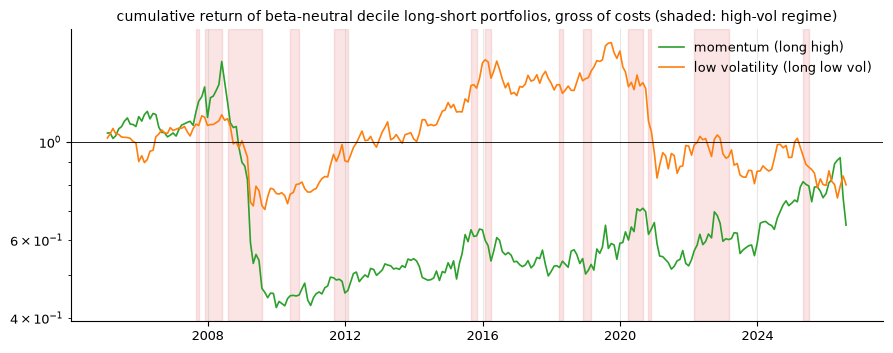

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for name, c in zip(ls_ret, ['C2', 'C1']):
    ax.plot((1 + ls_ret[name]).cumprod(), label=name, color=c, lw=1.2)
ax.fill_between(vol_reg.index, 0, 1, where=vol_reg == 2, transform=ax.get_xaxis_transform(), color='C3', alpha=0.12)
ax.axhline(1, color='k', lw=0.6); ax.set_yscale('log'); ax.legend(frameon=False)
ax.set_title('cumulative return of beta-neutral decile long-short portfolios, gross of costs (shaded: high-vol regime)', fontsize=10)
fig.tight_layout()

## 8. Robustness

Four variations of the section 6 comparison, each reported as mean IC by regime plus the Newey-West t-statistic of the high-minus-low difference. These are the pre-planned variations, not a search:

1. 21-day instead of 63-day realised volatility for the regime variable (same expanding terciles)
2. drawdown from the trailing 252-day high as the regime variable (expanding terciles of the drawdown depth, so regime 2 is the deepest third)
3. 3-month forward returns instead of 1-month (overlapping, so the HAC lag is set to 3)
4. raw instead of beta-adjusted forward returns

In [16]:
def regime_table(regime, target='fwdadj_1', lags=1):
    icx = rank_ic(panel, FEATS, target)
    rr = regime.reindex(icx.index)
    out = {}
    for f in FEATS:
        row = {f'ic {REGIME_NAMES[k]}': icx[f][rr == k].mean() for k in (0, 1, 2)}
        _, tv = regime_diff(icx[f], rr, lags)
        row['t (high - low)'] = tv.iloc[1]
        out[f] = row
    return pd.DataFrame(out).T

reg21, _, _ = expanding_tercile(state['mvol_21'])
regdd, _, _ = expanding_tercile(-state['drawdown'])
checks = {
    'baseline (63d vol, 1m, beta-adj)': regime_table(st['vol_regime']),
    '21d vol regime': regime_table(reg21.reindex(me)),
    'drawdown regime (2 = deepest)': regime_table(regdd.reindex(me)),
    '3m horizon (NW lag 3)': regime_table(st['vol_regime'], 'fwdadj_3', lags=3),
    'raw returns': regime_table(st['vol_regime'], 'fwd_1'),
}
rob = pd.concat(checks, names=['variant', 'signal'])
rob.round(3)

Out[16]: 
                                           ic low vol  ic mid vol  ic high vol  t (high - low)
variant                          signal                                                       
baseline (63d vol, 1m, beta-adj) mom_12m        0.028      -0.022       -0.017          -1.800
                                 rev_1m         0.001       0.016        0.011           0.510
                                 rvol_3m       -0.050      -0.033        0.009           2.501
                                 vol_surp      -0.003      -0.013        0.001           0.394
21d vol regime                   mom_12m        0.017      -0.001       -0.032          -1.943
                                 rev_1m         0.004       0.004        0.024           1.103
                                 rvol_3m       -0.033      -0.040       -0.007           1.024
                                 vol_surp      -0.001      -0.013       -0.003          -0.245
drawdown regime (2 = deepest)    mom_12m

In [17]:
sub = {}
for name, m in [('2005-2015', calib), ('2016-2026', evalm)]:
    for f in FEATS:
        sub[(name, f)] = {REGIME_NAMES[k]: IC[f][m & (vol_reg == k).values].mean() for k in (0, 1, 2)}
print('mean IC by volatility regime, split at the calibration boundary')
pd.DataFrame(sub).T.round(4)

mean IC by volatility regime, split at the calibration boundary
Out[17]: 
                    low vol  mid vol  high vol
2005-2015 mom_12m    0.0220   0.0056   -0.0248
          rev_1m     0.0005   0.0163    0.0081
          rvol_3m   -0.0337  -0.0558   -0.0179
          vol_surp  -0.0038  -0.0127   -0.0032
2016-2026 mom_12m    0.0342  -0.0481   -0.0097
          rev_1m     0.0023   0.0161    0.0142
          rvol_3m   -0.0683  -0.0116    0.0383
          vol_surp  -0.0015  -0.0127    0.0055


## 9. Results

Full sample (259 months, 2005-2026, beta-adjusted 1-month returns), the four signals reproduce the first project: only realised volatility has a clearly non-zero mean IC (-0.028, Newey-West t = -2.8), reversal is weakly positive (0.010, t = 1.4), momentum is flat (-0.003), volume surprise small and negative (-0.005). The point of this notebook is what these averages hide.

Volatility regime. Momentum and the low-volatility effect are both concentrated in calm markets. Momentum IC is +0.028 (t = 2.2) in the low-vol regime, -0.022 in mid-vol and -0.018 in high-vol; the mid-minus-low difference is -0.050 (t = -2.6) and high-minus-low is -0.045 (t = -1.8). Realised volatility has an IC of -0.050 (t = -3.8) in the low-vol regime, meaning low-volatility stocks strongly outperform when the market is calm, weakening to -0.033 in mid-vol and reversing to +0.009 in high-vol; the high-minus-low difference is +0.059 (t = 2.5). Reversal (0.002 / 0.016 / 0.011) and volume surprise are flat across regimes with no significant difference. So the two effects that carry any signal are the two that switch off, or reverse, when volatility is high.

Trend regime. Momentum is negative in down-trend months (-0.028) and flat in up-trend months (0.003), in the direction of the momentum-crash pattern, but the difference is not significant (t = 1.2), partly because only 50 of 259 months are down-trend. Nothing else differs by trend. The rolling-IC panels show the same picture: momentum IC turns sharply negative around 2008-2009 and 2020-2022, and the low-vol IC is most negative in the quiet mid-2010s.

Regime transfer. Weight vectors are the calibration-period (2005-2015) mean IC of each signal, estimated separately within each volatility regime and pooled. Evaluated out of sample (2016-2026), the transfer matrix is diagonal-heavy: weights calibrated in the low-vol regime score 0.074 in low-vol evaluation months but -0.033 in high-vol months, and weights calibrated in high-vol months score best in mid-vol evaluation months. Every calibration loses money in high-vol evaluation months (-0.008 to -0.035), so no historical environment produces weights that work when volatility is high later. Conditioning the combination on the regime at each forecast date raises the evaluation-period mean IC from 0.019 (unconditional, t = 1.3) to 0.030 (conditional, t = 2.2), but the 0.010 improvement is itself not significant (t = 1.1), and in-sample the same gap is 0.039 to 0.046. Of the twelve single-signal signs, nine carry their calibration sign into the same regime out of sample; the three that flip are mid-vol momentum, high-vol volatility and high-vol volume surprise, all in regimes where the calibration IC was already near zero.

Economic link. Beta-neutral decile long-short portfolios confirm the IC pattern. The momentum portfolio earns +1.09% per month (annualised Sharpe 1.0) in low-vol months, -0.51% in mid-vol and -0.90% in high-vol; the low-volatility portfolio earns +0.44% (Sharpe 0.4) in low-vol months and -0.93% in high-vol. Over the evaluation period the regime-conditional combined score has a gross Sharpe of 0.03 against -0.16 for the unconditional score, but both are negative after 10 bps per unit of turnover (turnover around 1.7 to 2.0 per month), so the conditioning changes the sign of the gross Sharpe without producing a portfolio that covers costs.

## 10. Limitations

- Survivorship. The universe is today's S&P 1500 membership, so delisted firms are absent and there are no delisting returns. This is not neutral across regimes: stocks that fell hard in a high-vol episode and are still in the index necessarily recovered, which mechanically lifts the forward returns of the high-volatility, low-momentum names that dominate the bottom of those signals in exactly those months. The high-vol regime results are the most exposed to this, and the reversal of the low-volatility effect in high-vol regimes should be read with that in mind rather than taken as a clean finding.
- Multiple testing. Section 6 runs eight regime-difference tests and section 8 adds four variants. The two effects highlighted (momentum and low volatility weakening with volatility) were the pre-specified hypotheses and both appear, but individual t-statistics near 2 are not adjusted for the number of tests. Under the alternative regime definitions the momentum effect weakens (high-minus-low t = -1.9 with 21-day vol, -1.2 with a drawdown regime) while the low-volatility effect stays strong at the 3-month horizon (t = 2.6); the momentum result is the less robust of the two.
- Regime imbalance. Because thresholds expand through time, the high-vol regime is only 68 of 259 months and is concentrated in 2008-2009, 2011, 2020 and 2022, so its statistics lean on a few episodes and the effective sample is smaller than the month count suggests.
- Persistence and horizon. Regimes are defined and returns measured monthly. The regime label is persistent, so consecutive months are not independent; HAC standard errors address the inference but not the small number of distinct high-vol episodes.
- Single market, single history. State variables come from SPY only. The expanding thresholds use 1993-onward SPY, but the stock panel and all IC estimates start in 2005, so the whole study is one 21-year sample of the US large- and mid-cap market.
- The transfer experiment fixes the calibration/evaluation split at 2015/2016 and uses IC-mean weights rather than a fitted model; a different split or a walk-forward scheme (as in the first project) could give a different conditional-minus-unconditional gap, and that gap is not significant here in any case.

## 11. Conclusion

The predictive content of these signals is regime-dependent rather than constant. Momentum and the low-volatility effect, the only two signals with any unconditional information, are both concentrated in calm markets and vanish or reverse when realised volatility is high; the difference is statistically clear for the low-volatility signal and borderline for momentum. A signal weighting calibrated in one volatility environment transfers well to the same environment and poorly to others, and no calibration works in high-vol months out of sample. Conditioning the signal combination on the observable volatility regime improves out-of-sample rank IC from 0.019 to 0.030, but the improvement is not statistically significant and does not survive transaction costs, so the honest reading is that market state clearly changes how these signals behave but does not, in this data, translate into a reliably better tradable model. The main caveat is survivorship: the high-volatility regime, where the most interesting reversals appear, is also where a current-constituent universe is most misleading.

In [18]:
print(f'total runtime: {time.time() - t_start:.0f}s')

total runtime: 43s
